In [58]:
#imports
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import PCA

In [59]:
#load data
DTM = pd.read_csv("DTM.csv", index_col="mag_id")
DTM

,aa,aaf,aaron,ababa,abandoned,abandonment,abbott,abc,abclou,abcparamount,...,zoomed,zooming,zoot,zor,zs,zumwalt,zunicia,zuniga,zurich,zw
mag_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,1,1,0,0,0,0
1,0,0,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,1,2,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2,1,0,0,0,0,0,7,0,0,...,0,1,0,0,0,0,1,2,0,0
4,0,0,0,0,0,0,0,5,1,0,...,0,0,2,0,0,0,0,0,0,0
5,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,3,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,2,0
7,0,0,6,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8,0,0,1,0,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0


In [60]:
# fit lda model
lda = LatentDirichletAllocation(n_components=5)
lda.fit(DTM)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [61]:
colors = 'YlGnBu'
n_topics = 5

lda_engine = LatentDirichletAllocation(n_components=n_topics,
                                       max_iter=20,
                                       learning_method="batch",
                                       random_state=42)

In [62]:
THETA = pd.DataFrame(lda_engine.fit_transform(DTM),index=DTM.index)
THETA.columns = [f"T{i:02d}" for i in range(n_topics)]
THETA

,T00,T01,T02,T03,T04
mag_id,,,,,
0,0.000013,0.000013,0.000013,0.000013,0.999949
1,0.000017,0.000017,0.000017,0.000017,0.999933
2,0.000014,0.000014,0.000014,0.000014,0.999943
3,0.000015,0.000015,0.000015,0.000015,0.999942
4,0.000014,0.000014,0.000014,0.000014,0.999945
5,0.000015,0.000015,0.000015,0.000015,0.999939
6,0.000016,0.000016,0.000016,0.000016,0.999935
7,0.178301,0.000017,0.000017,0.000017,0.821649
8,0.000016,0.000016,0.000016,0.000016,0.999935


In [63]:
THETA.T.style.background_gradient(cmap=colors, axis=None)

mag_id,0,1,2,3,4,5,6,7,8,9
T00,0.000013,0.000017,0.000014,0.000015,0.000014,0.000015,0.000016,0.178301,0.000016,0.000017
T01,0.000013,0.000017,0.000014,0.000015,0.000014,0.000015,0.000016,0.000017,0.000016,0.000016
T02,0.000013,0.000017,0.000014,0.000015,0.000014,0.000015,0.000016,0.000017,0.000016,0.000016
T03,0.000013,0.000017,0.000014,0.000015,0.000014,0.000015,0.000016,0.000017,0.000016,0.000016
T04,0.999949,0.999933,0.999943,0.999942,0.999945,0.999939,0.999935,0.821649,0.999935,0.999934


In [64]:
# phi topic term matrix
PHI = pd.DataFrame(lda_engine.components_ / lda_engine.components_.sum(axis=1)[:, None], columns=DTM.columns)

PHI.index = [f"T{i:02d}" for i in range(n_topics)]
PHI.index.name = "topic_id"
PHI

,aa,aaf,aaron,ababa,abandoned,abandonment,abbott,abc,abclou,abcparamount,...,zoomed,zooming,zoot,zor,zs,zumwalt,zunicia,zuniga,zurich,zw
topic_id,,,,,,,,,,,,,,,,,,,,,
T00,0.000037,0.000037,0.000926,0.000037,0.000037,0.000037,0.000037,0.000037,0.000037,0.000037,...,0.000037,0.000037,0.000037,0.000037,0.000037,0.000037,0.000037,0.000037,0.000038,0.000037
T01,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,...,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061
T02,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,...,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061
T03,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,...,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061
T04,0.000017,0.000009,0.000048,0.000009,0.000017,0.000009,0.000009,0.000122,0.000009,0.000009,...,0.000009,0.000009,0.000017,0.000009,0.000009,0.000009,0.000009,0.000017,0.000039,0.000009


In [65]:
PHI.T.sample(10).T.style.background_gradient(cmap=colors, axis=None)

,spread,homers,eyebrow,grammies,cheryl,crying,rivera,mounts,ft,constantino
topic_id,,,,,,,,,,
T00,0.000037,0.000365,0.000037,0.000037,0.000037,0.000172,0.000037,0.000037,0.000201,0.000037
T01,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061
T02,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061
T03,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061,0.000061
T04,0.000054,0.000011,0.000009,0.000009,0.000017,0.000011,0.000009,0.000009,0.000040,0.000009


In [66]:
# Create TOPICS and get Top Terms per Topic
TOPICS = PHI.stack().to_frame("topic_weight")
TOPICS.index.names = ["topic_id", "term_str"]

TOPICS["term_rank"] = TOPICS.groupby("topic_id").topic_weight.rank(
    method="first", ascending=False)

TOPICS = TOPICS.sort_values(["topic_id", "term_rank"])
TOPICS

topic_weight  term_rank
topic_id term_str                         
T00      ruby          0.004912        1.0
         she           0.002712        2.0
         sam           0.002144        3.0
         minnie        0.001705        4.0
         february      0.001694        5.0
...                         ...        ...
T04      suwannee      0.000002    16283.0
         kwame         0.000002    16284.0
         collie        0.000002    16285.0
         ye            0.000002    16286.0
         mccollum      0.000002    16287.0

[81435 rows x 2 columns]

In [67]:
# top 5 words per topic
TOP_TERMS = TOPICS[TOPICS.term_rank <= 5].reset_index()
TOP_TERMS

,topic_id,term_str,topic_weight,term_rank
0,T00,ruby,0.004912,1.0
1,T00,she,0.002712,2.0
2,T00,sam,0.002144,3.0
3,T00,minnie,0.001705,4.0
4,T00,february,0.001694,5.0
5,T01,amused,0.000061,1.0
6,T01,asphalt,0.000061,2.0
7,T01,astute,0.000061,3.0
8,T01,berlin,0.000061,4.0
9,T01,casket,0.000061,5.0


In [68]:
# sort docs by doc weight
TOPICS_5 = TOPICS[TOPICS['term_rank'] <= 5].copy()

TOPICS_5['doc_weight_sum'] = TOPICS_5.index.get_level_values('topic_id').map(THETA.sum())
TOPICS_5['term_freq'] = TOPICS_5.index.get_level_values('topic_id').map(PHI.sum(1) / PHI.sum(1).sum())
TOPICS_5.sort_values('doc_weight_sum', ascending=False).style.background_gradient(cmap='YlGnBu', axis=0)

<Axes: ylabel='top_terms'>

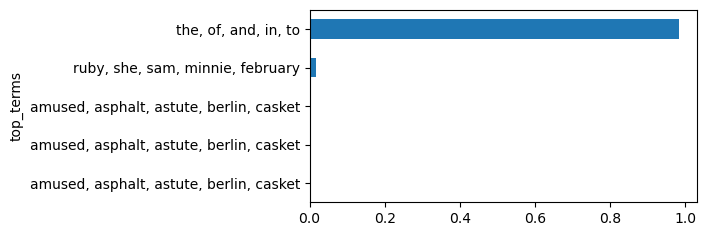

In [69]:
TOPIC_SUMMARY.sort_values("doc_weight_mean", ascending=True).plot.barh(y="doc_weight_mean",
                                                                       x="top_terms",
                                                                       figsize=(5, n_topics/2),
                                                                       legend=False)

In [70]:
TOPIC_MEANS = THETA.mean().to_frame("mean_doc_weight")

TOP_WORDS = TOP_TERMS.pivot(index="topic_id",
                            columns="term_rank",
                            values="term_str")
TOP_WORDS["top_terms"] = TOP_WORDS.apply(lambda x: ", ".join(x), axis=1)

LDA_SUMMARY = TOPIC_MEANS.join(TOP_WORDS[["top_terms"]])
LDA_SUMMARY

,mean_doc_weight,top_terms
T00,0.017844,"ruby, she, sam, minnie, february"
T01,0.000015,"amused, asphalt, astute, berlin, casket"
T02,0.000015,"amused, asphalt, astute, berlin, casket"
T03,0.000015,"amused, asphalt, astute, berlin, casket"
T04,0.982110,"the, of, and, in, to"


In [71]:
LIB = pd.read_csv("data/LIB.csv", index_col="mag_id")

topic_pca = PCA(n_components=2, random_state=42)

TOPIC_PCA = pd.DataFrame(topic_pca.fit_transform(THETA.T),
                         index=THETA.columns,
                         columns=["PC0", "PC1"])
TOPIC_PCA["mean_doc_weight"] = THETA.mean()

TOPIC_QUARTER = THETA.join(LIB[["quarter"]]).groupby("quarter").mean().idxmax()

TOPIC_PCA["dominant_quarter"] = TOPIC_QUARTER

In [72]:
px.scatter(
    TOPIC_PCA.reset_index(),
    x="PC0",
    y="PC1",
    size="mean_doc_weight",
    color="dominant_quarter",
    hover_name="index",
    title="PCA of LDA Topics by Dominant Quarter",
    height=500,
    width=700)

### INTERPRETATION
- One topic, T04, clearly stands out. It is much larger and more spread out than the others along PC0, 
which means it shows up the most across the documents and drives most of the variation. Based on its top
words, it seems to represent general language. The other topics are clustered closer together, which
suggests they are less distinct and share more similar language.

In [73]:
# save the model and data
THETA.to_csv("LDA_THETA.csv")
PHI.to_csv("LDA_PHI.csv")
LDA_SUMMARY.to_csv("LDA_TOPIC_SUMMARY.csv")